# DecodeLabs AI — Project 2: Data Classification Using AI
## Industrial Training Kit | Batch 2026

**Author:** Ali Ahmad  
**Track:** Supervised Learning  
**Algorithm:** K-Nearest Neighbours (KNN) + Multi-Model Comparison  
**Dataset:** Iris Benchmark (150 samples · 3 classes · 4 features)

---
### Project Pipeline
```
Raw Data → EDA → Preprocessing → KNN Elbow → Model Training
         → Evaluation → Ensemble → SHAP → Learning Curve → Report
```

### 🎯 Objectives
1. Load and explore the Iris dataset
2. Apply feature scaling and perform stratified train-test split
3. Determine optimal *k* via elbow method
4. Train KNN, Decision Tree, SVM, Logistic Regression, and Voting Ensemble
5. Evaluate with Accuracy, F1, Precision, Recall, ROC-AUC, and Confusion Matrix
6. Explain predictions using SHAP
7. Produce a final Model Card


In [2]:
# Cell 2 — Install dependencies (run once; safe to skip if already installed)
import subprocess, sys

packages = [
    'scikit-learn', 'pandas', 'matplotlib',
    'seaborn', 'shap', 'datasets', 'scipy', 'joblib',
]

# Install everything else first
for pkg in packages:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '--upgrade', pkg, '-q'],
        capture_output=True
    )

# Pin numpy LAST so nothing overwrites it
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'numpy<2', '-q'],
    capture_output=True
)

print("✅ All dependencies installed / verified.")


✅ All dependencies installed / verified.


In [3]:
%pip install --upgrade bottleneck

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Cell 3 — Imports
import os, sys, warnings, datetime, hashlib, json
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                       cross_val_score, learning_curve)
from sklearn.preprocessing    import StandardScaler, label_binarize
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.tree             import DecisionTreeClassifier, plot_tree
from sklearn.svm              import SVC
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import VotingClassifier
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (accuracy_score, f1_score, precision_score,
                                       recall_score, roc_auc_score,
                                       classification_report, confusion_matrix,
                                       roc_curve, auc, make_scorer)
from sklearn.calibration      import calibration_curve
from sklearn.base             import clone
import shap
import joblib


In [5]:
# ── Pipeline module imports ───────────────────────────────────────────────────
sys.path.insert(0, os.path.abspath('..'))

from pipeline.data_loader  import load_data, FEATURE_NAMES, TARGET_NAMES
from pipeline.preprocessor import (split_features_target, stratified_split,
                                    scale_features, detect_outliers_iqr,
                                    validate_shapes)
from pipeline.trainer      import (train_knn, train_decision_tree, train_svm,
                                    train_logistic_regression, train_all_models,
                                    build_voting_classifier, build_pipeline)
from pipeline.evaluator    import (compute_metrics, full_report,
                                    cross_validate_all,
                                    statistical_significance_test,
                                    weighted_f1, compute_weighted_f1,
                                    make_weighted_scorer,
                                    compute_calibration_score, log_experiment)
from pipeline.visualizer   import (plot_class_distribution,
                                    plot_feature_distributions,
                                    plot_correlation_heatmap, plot_pairplot,
                                    plot_boxplots, plot_violin,
                                    plot_scaling_comparison, plot_knn_elbow,
                                    plot_model_comparison, plot_cv_boxplot,
                                    plot_confusion_matrix, plot_roc_curves,
                                    plot_decision_tree, plot_feature_importance,
                                    plot_calibration_curves, plot_shap_summary,
                                    plot_learning_curve)


In [6]:
# ── Global settings ───────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'font.family': 'DejaVu Sans'})
sns.set_theme(style='whitegrid', palette='muted')

# ── Base project path — change only this one line if you move the project ──
BASE_DIR  = r"C:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2"
MODEL_DIR = os.path.join(BASE_DIR, 'models')
ASSET_DIR = os.path.join(BASE_DIR, 'assets')
LOG_DIR   = os.path.join(BASE_DIR, 'logs')
LOG_FILE  = os.path.join(LOG_DIR,  'experiment_log.csv')

for d in [MODEL_DIR, ASSET_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"✅ Ready: {d}")

RANDOM_STATE = 42
TEST_SIZE    = 0.20
print("✅ All imports successful.")
print(f"   Working directory : {os.getcwd()}")

✅ Ready: C:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\models
✅ Ready: C:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\assets
✅ Ready: C:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\logs
✅ All imports successful.
   Working directory : c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks


## Section 1 — Data Loading

Load the Iris dataset from HuggingFace (`scikit-learn/iris`).  
Fallback: sklearn built-in if HuggingFace is unavailable.  
A **SHA-256 hash** is computed for data versioning and reproducibility audit.


In [7]:
# Cell 5 — Load data (HuggingFace with sklearn fallback)
df, data_hash, source_used = load_data()

print(f"\n{'='*55}")
print(f"  Source     : {source_used}")
print(f"  Shape      : {df.shape}")
print(f"  Columns    : {list(df.columns)}")
print(f"  Data hash  : {data_hash[:16]}...  (SHA-256)")
print(f"  Loaded at  : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'='*55}")


[DataLoader] Source: HuggingFace (scikit-learn/iris)
[DataLoader] DataFrame shape : (150, 6)
[DataLoader] Hash computed at: 2026-05-27T20:31:51.284478

  Source     : huggingface
  Shape      : (150, 6)
  Columns    : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target', 'species']
  Data hash  : 67037d1d5dd80fe8...  (SHA-256)
  Loaded at  : 2026-05-27 20:31:51


In [8]:
# Cell 6 — Preview the dataset
print("First 5 rows: ")
display(df.head())

print("\nData types: ")
display(df.dtypes.to_frame(name='dtype').T)

print("\nValue counts per species: ")
display(df['species'].value_counts().to_frame())


First 5 rows: 


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Data types: 


,sepal_length,sepal_width,petal_length,petal_width,target,species
dtype,float64,float64,float64,float64,int64,str



Value counts per species: 


,count
species,
setosa,50
versicolor,50
virginica,50


In [9]:
# Cell 7 — Statistical summary
print("Descriptive Statistics: ")
display(df[FEATURE_NAMES].describe().round(4))

# Per-class statistics
print("\nPer-class Mean Values: ")
display(df.groupby('species')[FEATURE_NAMES].mean().round(4))


Descriptive Statistics: 


,sepal_length,sepal_width,petal_length,petal_width
count,150.0000,150.0000,150.0000,150.0000
mean,5.8433,3.0540,3.7587,1.1987
std,0.8281,0.4336,1.7644,0.7632
min,4.3000,2.0000,1.0000,0.1000
25%,5.1000,2.8000,1.6000,0.3000
50%,5.8000,3.0000,4.3500,1.3000
75%,6.4000,3.3000,5.1000,1.8000
max,7.9000,4.4000,6.9000,2.5000



Per-class Mean Values: 


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


## Section 2 — Exploratory Data Analysis (EDA)

Six visualisations that build domain understanding before modelling:

> Class Distribution | Verify class balance  
> Feature Distributions | KDE per class per feature  
> Correlation Heatmap | Detect multicollinearity  
> Pairplot | All feature-pair scatter + KDE diagonal  
> Box Plots | IQR, spread, outlier inspection  
> Violin Plots | Distribution shape per class   

> **Key insight:** Setosa is linearly separable. Versicolor/Virginica overlap,  
> motivating a distance-based and kernel-based model comparison.


[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\class_distribution.png


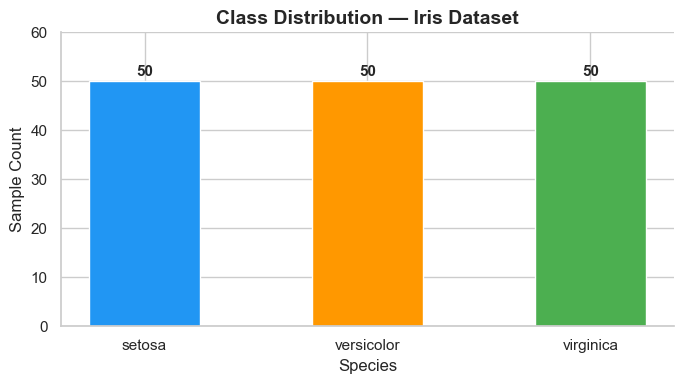

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\class_distribution.png


In [10]:
# Cell 9 — Class distribution bar chart
path = plot_class_distribution(df)
plt.show()
print(f"Saved: {path}")

[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\feature_distributions.png


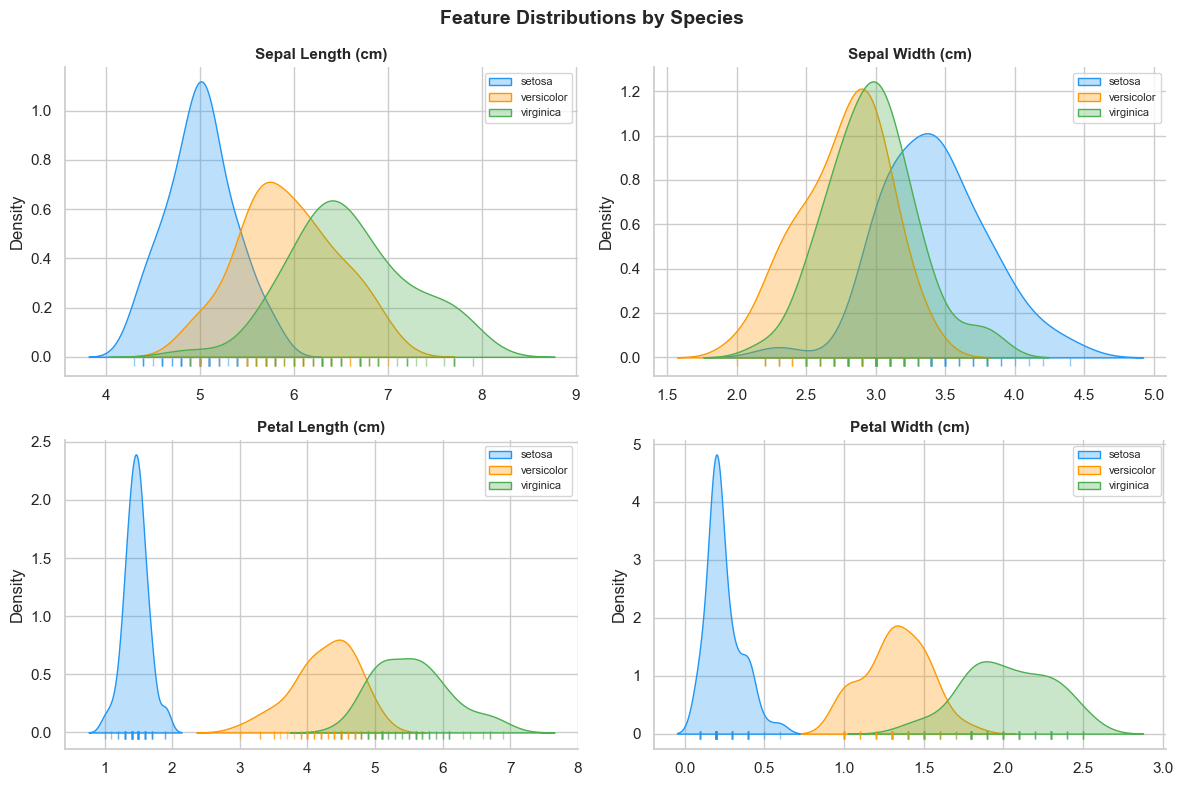

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\feature_distributions.png


In [11]:
# Cell 10 — Feature KDE + rug plots
path = plot_feature_distributions(df)
plt.show()
print(f"Saved: {path}")

[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\correlation_heatmap.png


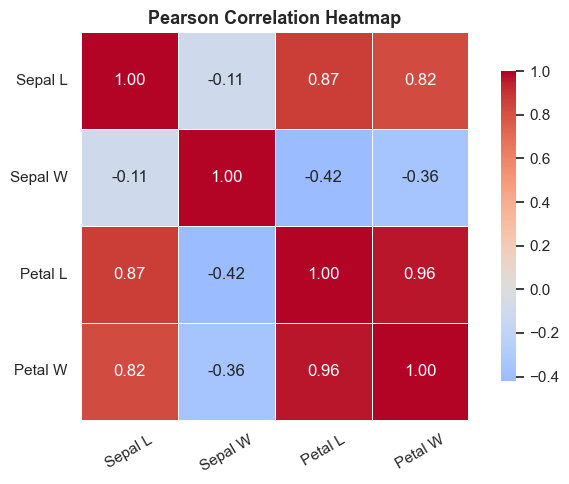

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\correlation_heatmap.png

Highly correlated feature pairs (|r| > 0.8):
  petal_length ↔ sepal_length : 0.872
  petal_length ↔ petal_width : 0.963
  petal_width ↔ sepal_length : 0.818


In [12]:
# Cell 11 — Pearson correlation heatmap
path = plot_correlation_heatmap(df)
plt.show()
print(f"Saved: {path}")

# Print numeric interpretation
corr = df[FEATURE_NAMES].corr()
high_corr = [(r, c, corr.loc[r, c])
             for r in corr.index for c in corr.columns
             if r < c and abs(corr.loc[r, c]) > 0.8]
print("\nHighly correlated feature pairs (|r| > 0.8):")
for r, c, val in high_corr:
    print(f"  {r} ↔ {c} : {val:.3f}")


[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\pairplot.png


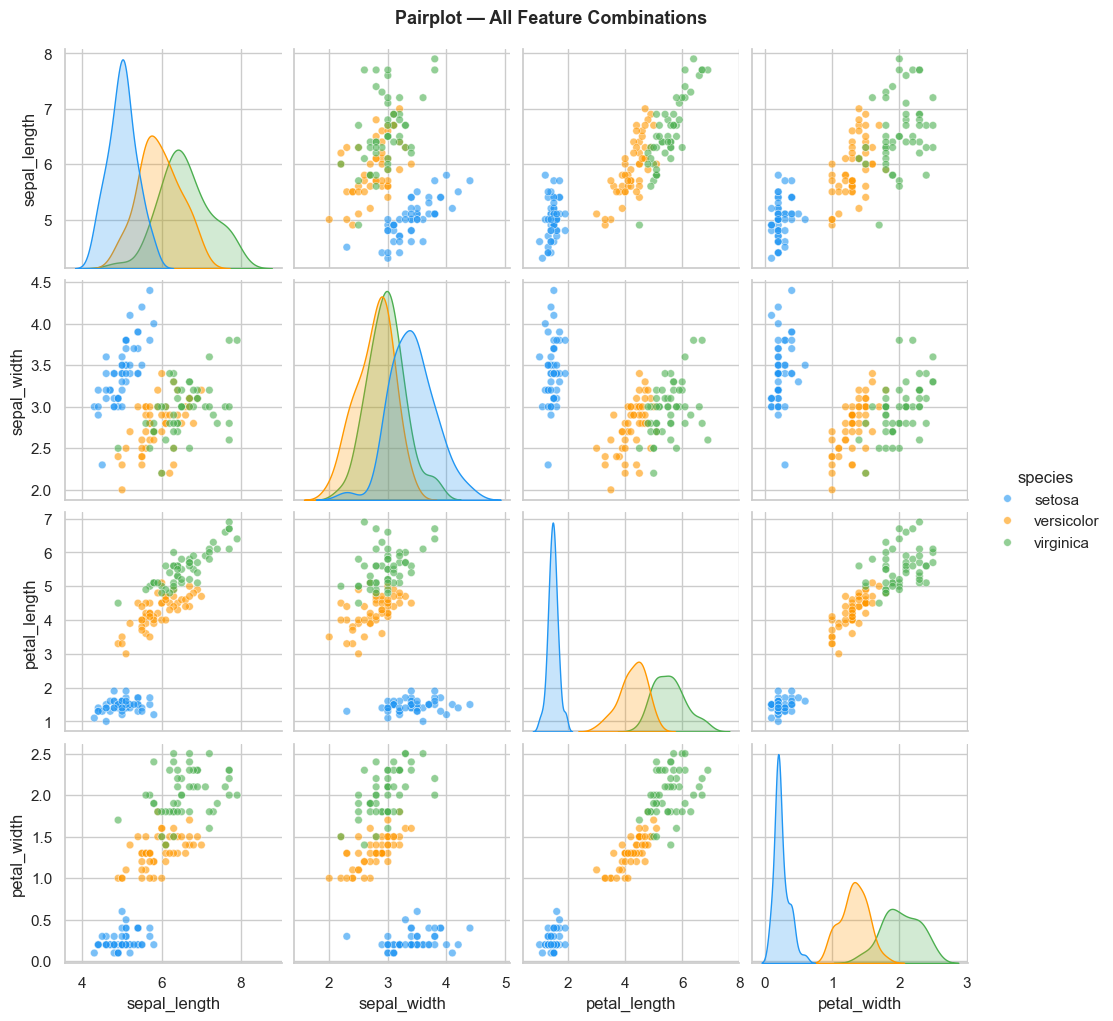

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\pairplot.png


In [13]:
# Cell 12 — Pairplot (all feature combinations)
path = plot_pairplot(df)
plt.show()
print(f"Saved: {path}")

[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\boxplots.png


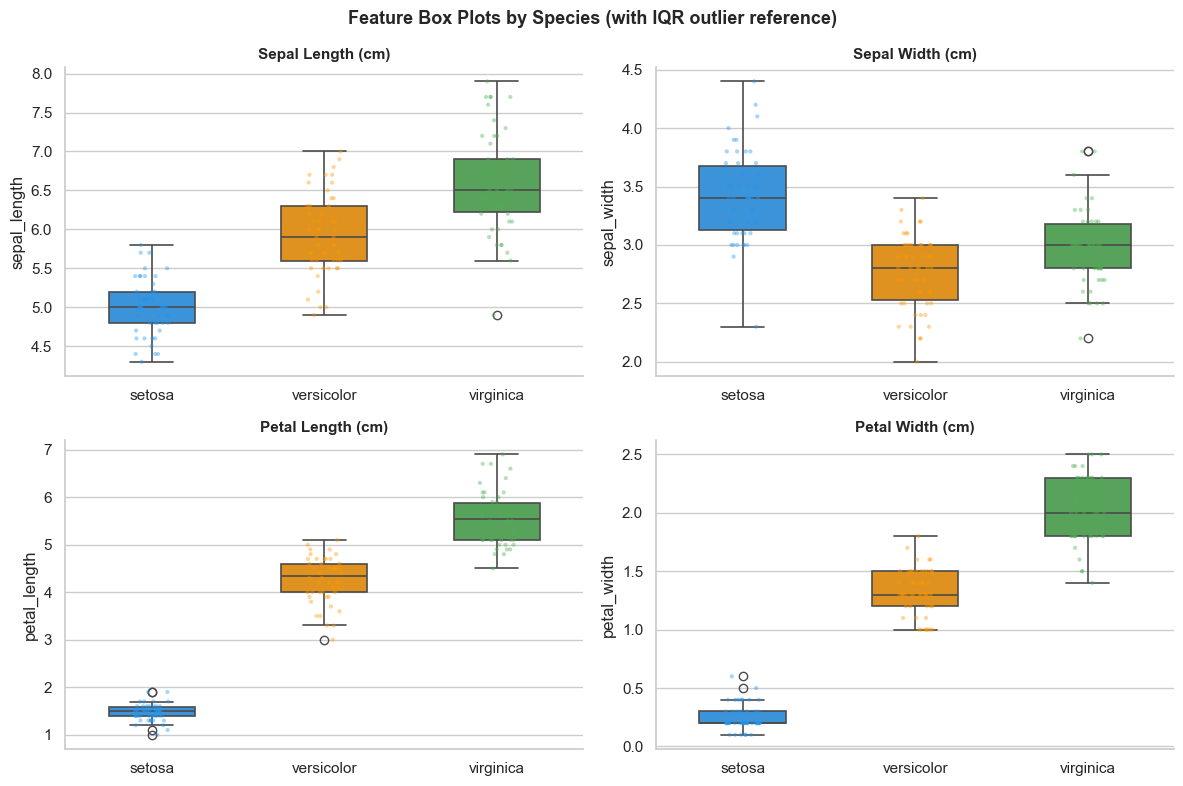

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\boxplots.png


In [14]:
# Cell 13 — Box plots (IQR + strip overlay)
path = plot_boxplots(df)
plt.show()
print(f"Saved: {path}")

[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\violin_plots.png


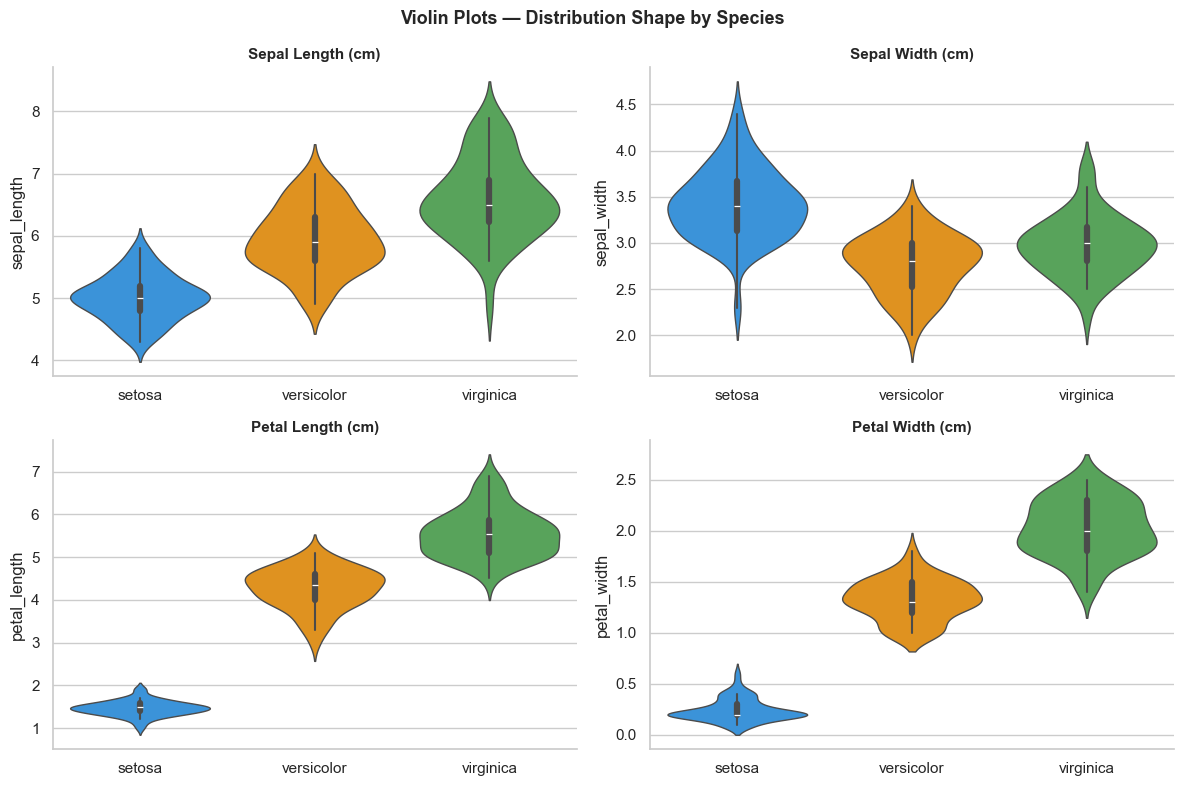

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\violin_plots.png

IQR Outlier Detection Report: 


,feature,class,n_outliers
2,sepal_length,virginica,1
5,sepal_width,virginica,3
6,petal_length,setosa,4
7,petal_length,versicolor,1
9,petal_width,setosa,2



Total outliers detected across all features/classes: 11
Action: Outliers retained — IQR method identifies,
        but Iris outliers are genuine botanical variation, not errors.


In [15]:
# Cell 14 — Violin plots + IQR outlier detection report
path = plot_violin(df)
plt.show()
print(f"Saved: {path}")

print("\nIQR Outlier Detection Report: ")
outlier_df = detect_outliers_iqr(df)
display(outlier_df[outlier_df['n_outliers'] > 0][['feature', 'class', 'n_outliers']])
total_outliers = outlier_df['n_outliers'].sum()
print(f"\nTotal outliers detected across all features/classes: {total_outliers}")
print("Action: Outliers retained — IQR method identifies,")
print("        but Iris outliers are genuine botanical variation, not errors.")

## Section 3 — Preprocessing

**Pipeline:**
1. **Feature / Target split** — X (4 features) and y (species string)
2. **Stratified train-test split** — 80% train / 20% test, shuffled
3. **StandardScaler** — fit on train only (strict anti-leakage rule)
4. **Shape validation** — automated assertions before any model sees data

> **Anti-leakage rule:** The scaler's `.fit()` call sees **only X_train**.  
> `.transform()` is applied to X_test using the training statistics.  
> Fitting on all data before splitting would inflate test-set scores.


In [16]:
# Cell 16 — Feature/Target split, stratified split, StandardScaler
X, y = split_features_target(df)

X_train, X_test, y_train, y_test = stratified_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

validate_shapes(X_train, X_test, y_train, y_test,
                X_train_scaled, X_test_scaled)

print(f"\n{'='*50}")
print(f"  X_train        : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_test         : {X_test.shape}    y_test  : {y_test.shape}")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")
print(f"{'='*50}")
print(f"\nScaler mean    : {scaler.mean_.round(4)}")
print(f"Scaler std     : {scaler.scale_.round(4)}")
print(f"\n✅ Shape validation passed. No data leakage detected.")



  X_train        : (120, 4)   y_train : (120,)
  X_test         : (30, 4)    y_test  : (30,)
  X_train_scaled : (120, 4)
  X_test_scaled  : (30, 4)

Scaler mean    : [5.8417 3.0442 3.7708 1.2042]
Scaler std     : [0.8374 0.4438 1.76   0.7606]

✅ Shape validation passed. No data leakage detected.


[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\scaling_comparison.png


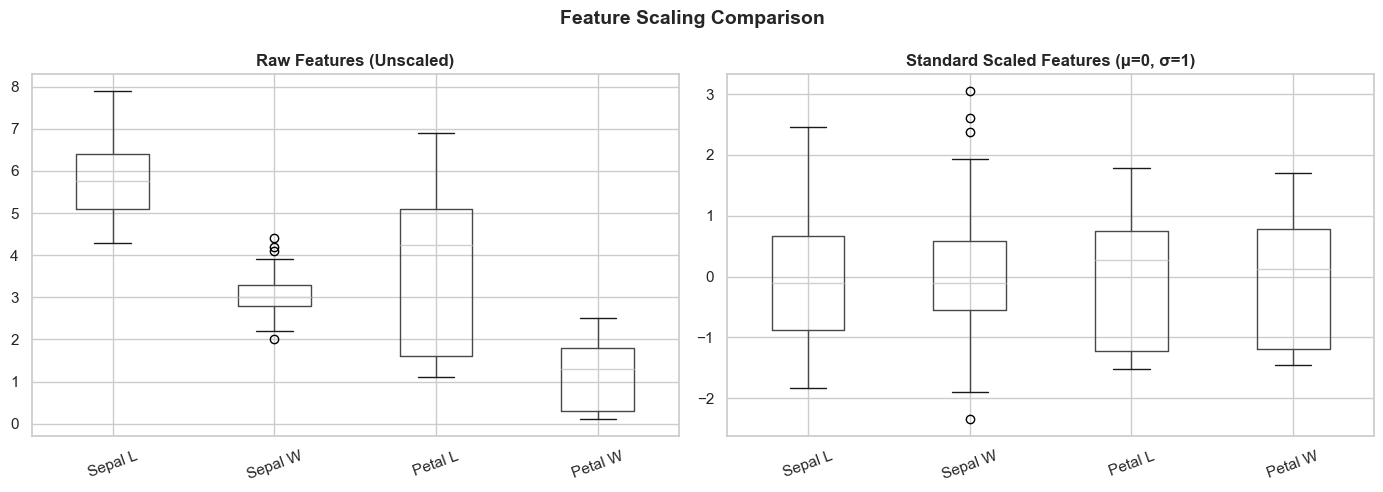

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\scaling_comparison.png

Train set class distribution (stratified check):
species
setosa        40
virginica     40
versicolor    40

Test set class distribution (stratified check):
species
setosa        10
virginica     10
versicolor    10


In [17]:
# Cell 17 — Raw vs scaled feature distribution comparison
path = plot_scaling_comparison(X_train, X_train_scaled)
plt.show()
print(f"Saved: {path}")

print("\nTrain set class distribution (stratified check):")
print(y_train.value_counts().to_string())
print("\nTest set class distribution (stratified check):")
print(y_test.value_counts().to_string())


## Section 3.5 — Dimensionality Reduction (PCA + t-SNE)

Projecting 4D Iris features into 2D to visualise natural class separability
before modelling begins.

- **PCA** — linear projection maximising variance. Fast, deterministic.
- **t-SNE** — non-linear manifold projection. Preserves local cluster structure.

Both use the **scaled** training+test combined array so units are consistent.

PCA Explained Variance
  PC1 : 73.41%
  PC2 : 22.37%
  Total captured : 95.78%
['setosa' 'virginica' 'versicolor' 'setosa' 'versicolor' 'virginica'
 'versicolor' 'virginica' 'virginica' 'virginica']
object


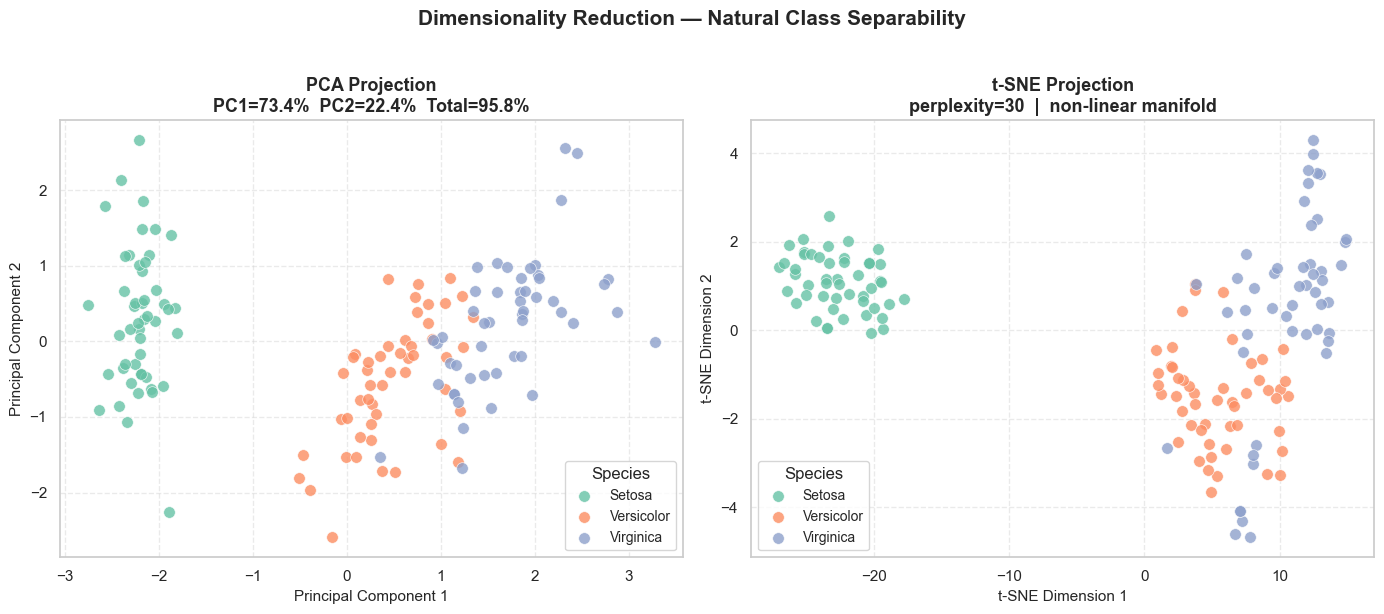

Saved: C:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\assets\pca_tsne_projection.png

Interpretation
  Setosa is linearly separable from the other two classes.
  Versicolor and Virginica overlap slightly — confirming
  that a non-linear boundary (SVM/KNN) will outperform
  a linear classifier on those two classes.


In [18]:
# ── PCA + t-SNE Dimensionality Reduction ─────────────────────────────────────
# Combine scaled train + test back into one array for full-dataset projection
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])   # (150, 4)
y_all        = np.concatenate([y_train, y_test])             # (150,)

# ── PCA ───────────────────────────────────────────────────────────────────────
pca          = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca        = pca.fit_transform(X_all_scaled)
var_ratio    = pca.explained_variance_ratio_

print("="*60)
print("PCA Explained Variance")
print("="*60)
print(f"  PC1 : {var_ratio[0]*100:.2f}%")
print(f"  PC2 : {var_ratio[1]*100:.2f}%")
print(f"  Total captured : {sum(var_ratio)*100:.2f}%")

# ── t-SNE ─────────────────────────────────────────────────────────────────────
tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=30,
    learning_rate='auto',
    init='pca'
)  # removed unsupported `n_iter` argument
X_tsne = tsne.fit_transform(X_all_scaled)

# ── Plot ──────────────────────────────────────────────────────────────────────
palette     = sns.color_palette("Set2", n_colors=3)
class_order = TARGET_NAMES                  # ['setosa','versicolor','virginica']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

print(y_all[:10])
print(y_all.dtype)

for ax, X_proj, title_prefix in zip(
        axes,
        [X_pca, X_tsne],
        ['PCA', 't-SNE']):

    for idx, cls in enumerate(class_order):
        mask = (y_all == cls)               # boolean mask for this class
        ax.scatter(
            X_proj[mask, 0], X_proj[mask, 1],
            label=cls.capitalize(),
            color=palette[idx],
            alpha=0.8,
            edgecolors='white',
            linewidths=0.5,
            s=70
        )

    if title_prefix == 'PCA':
        ax.set_title(
            f'PCA Projection\n'
            f'PC1={var_ratio[0]*100:.1f}%  PC2={var_ratio[1]*100:.1f}%  '
            f'Total={sum(var_ratio)*100:.1f}%',
            fontsize=13, fontweight='bold'
        )
        ax.set_xlabel('Principal Component 1', fontsize=11)
        ax.set_ylabel('Principal Component 2', fontsize=11)
    else:
        ax.set_title(
            't-SNE Projection\n'
            'perplexity=30  |  non-linear manifold',
            fontsize=13, fontweight='bold'
        )
        ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
        ax.set_ylabel('t-SNE Dimension 2', fontsize=11)

    ax.legend(title='Species', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle(
    'Dimensionality Reduction — Natural Class Separability',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()

# Save to assets
pca_path = os.path.join(ASSET_DIR, 'pca_tsne_projection.png')
plt.savefig(pca_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {pca_path}")

# ── Interpretation ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("Interpretation")
print("="*60)
print("  Setosa is linearly separable from the other two classes.")
print("  Versicolor and Virginica overlap slightly — confirming")
print("  that a non-linear boundary (SVM/KNN) will outperform")
print("  a linear classifier on those two classes.")

## Section 4 — KNN Hyperparameter Tuning (Elbow Method)

**Why k matters:**
- **k=1** → overfitting (memorises training noise)
- **k=100** → underfitting (boundary too coarse)
- **Optimal k** → the "elbow" where CV error rate stops dropping significantly

We sweep k ∈ {1, 3, 5, 7, 9, 11, 13, 15} using 5-fold stratified cross-validation  
scoring on macro-F1.


In [19]:
# Cell 19 — KNN elbow method sweep
k_values    = list(range(1, 16, 2))   # [1, 3, 5, 7, 9, 11, 13, 15]
error_rates = []
cv_knn      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("k     Mean F1    Error Rate")
print("-" * 35)
for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    scores  = cross_val_score(knn_tmp, X_train_scaled, y_train,
                               cv=cv_knn, scoring='f1_macro')
    err     = 1 - scores.mean()
    error_rates.append(err)
    print(f"k={k:<3}  {scores.mean():.4f}      {err:.4f}")

# Identify optimal k (lowest error rate; prefer lower k on tie)
optimal_k = k_values[int(np.argmin(error_rates))]
print(f"\n✅ Optimal k selected: {optimal_k}")


k     Mean F1    Error Rate
-----------------------------------
k=1    0.9499      0.0501
k=3    0.9665      0.0335
k=5    0.9580      0.0420
k=7    0.9333      0.0667
k=9    0.9499      0.0501
k=11   0.9498      0.0502
k=13   0.9499      0.0501
k=15   0.9244      0.0756

✅ Optimal k selected: 3


[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\knn_elbow.png


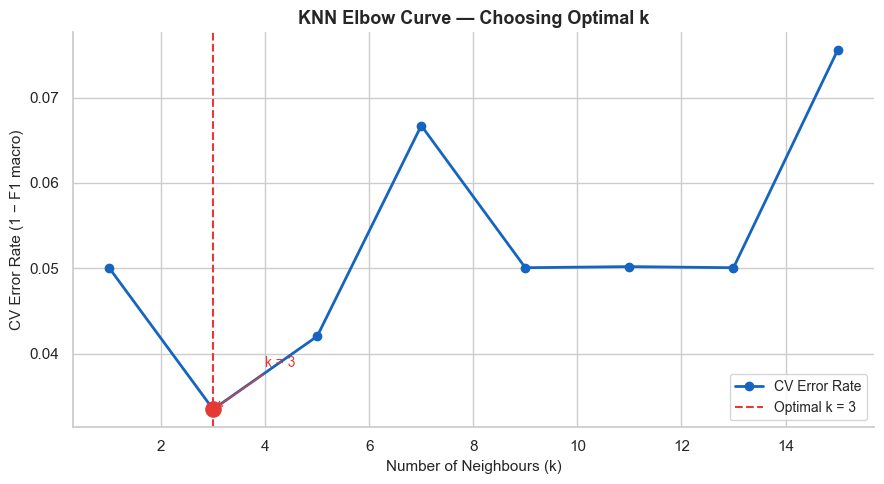

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\knn_elbow.png
Optimal k = 3  |  Error rate = 0.0335  |  F1 = 0.9665


In [20]:
# Cell 20 — Elbow curve visualisation
path = plot_knn_elbow(k_values, error_rates, optimal_k)
plt.show()
print(f"Saved: {path}")
print(f"Optimal k = {optimal_k}  |  "
      f"Error rate = {error_rates[k_values.index(optimal_k)]:.4f}  |  "
      f"F1 = {1 - error_rates[k_values.index(optimal_k)]:.4f}")


## Section 5 — Model Training
Four base classifiers + one soft-voting ensemble:

> **KNN** | k = optimal_k | Distance-based, no training phase   
> **Decision Tree** | max_depth=5 | Interpretable, Gini split   
> **SVM** | RBF kernel, C=1 | probability=True for ROC/SHAP   
> **Logistic Regression** | max_iter=1000 | Linear baseline  
> **Voting Ensemble** | soft voting | Averages probabilities   

All models trained on **X_train_scaled** — the anti-leakage-clean set.


In [21]:
# Cell 22 — Train all 5 models
models = train_all_models(X_train_scaled, y_train, optimal_k=optimal_k)

print("\n✅ Models trained:")
for name, model in models.items():
    print(f"   {name:<22}  → {type(model).__name__}")


[Trainer] KNN (k=3) trained.
[Trainer] Decision Tree (max_depth=5) trained.
[Trainer] SVM (RBF kernel, probability=True) trained.
[Trainer] Logistic Regression (max_iter=1000) trained.
[Trainer] Soft Voting Ensemble trained.
[Trainer] All 5 models trained successfully.

✅ Models trained:
   KNN                     → KNeighborsClassifier
   Decision Tree           → DecisionTreeClassifier
   SVM                     → SVC
   Logistic Regression     → LogisticRegression
   Ensemble                → VotingClassifier


## Section 6 — Model Evaluation

**Metrics computed for every model:**

> Accuracy | TP+TN / all | Overall correctness    
> F1 (macro) | harmonic mean of P & R | Balanced across classes    
> Precision | TP / (TP+FP) | Quality of positive predictions    
> Recall | TP / (TP+FN) | Coverage of actual positives   
> ROC-AUC | area under ROC | Discrimination at all thresholds   

> **Why F1 and not just accuracy?**  
> On balanced data like Iris both are similar, but F1 is more robust  
> to class imbalance — a critical habit to build from the start.


In [ ]:
# Cell 24 — Compute and display all metrics
results = {name: compute_metrics(model, X_test_scaled, y_test) for name, model in models.items()}
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'

print(type(results_df))
print(results_df.dtypes)
print(results_df.head())

<class 'pandas.DataFrame'>
accuracy     float64
f1           float64
precision    float64
recall       float64
roc_auc      float64
dtype: object
                     accuracy      f1  precision  recall  roc_auc
Model                                                            
KNN                    0.9333  0.9327     0.9444  0.9333   0.9933
Decision Tree          0.9000  0.8997     0.9024  0.9000   0.9250
SVM                    0.9667  0.9666     0.9697  0.9667   0.9967
Logistic Regression    0.9333  0.9333     0.9333  0.9333   0.9967
Ensemble               0.9000  0.8997     0.9024  0.9000   0.9933


In [23]:
print("\nModel Metrics Summary:")
display(results_df.round(4))


Model Metrics Summary:


,accuracy,f1,precision,recall,roc_auc
Model,,,,,
KNN,0.9333,0.9327,0.9444,0.9333,0.9933
Decision Tree,0.9000,0.8997,0.9024,0.9000,0.9250
SVM,0.9667,0.9666,0.9697,0.9667,0.9967
Logistic Regression,0.9333,0.9333,0.9333,0.9333,0.9967
Ensemble,0.9000,0.8997,0.9024,0.9000,0.9933


In [25]:
# Cell 25 — Full per-class classification reports
for name, model in models.items():
    full_report(name, model, X_test_scaled, y_test)
    print()


  MODEL: KNN
  Accuracy  : 0.9333
  F1 (macro): 0.9327
  Precision : 0.9444
  Recall    : 0.9333
  ROC-AUC   : 0.9933

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


  MODEL: Decision Tree
  Accuracy  : 0.9000
  F1 (macro): 0.8997
  Precision : 0.9024
  Recall    : 0.9000
  ROC-AUC   : 0.9250

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90 

[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\model_comparison.png


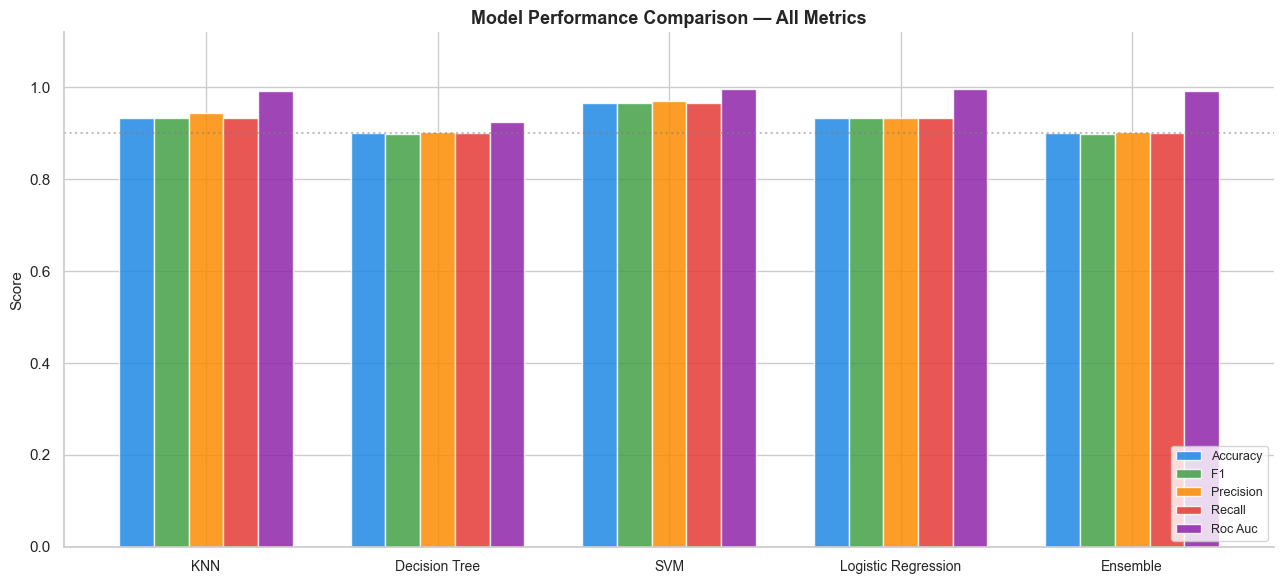

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\model_comparison.png

🏆 Best model by F1: SVM  (F1 = 0.9666)


In [26]:
# Cell 26 — Model comparison grouped bar chart
path = plot_model_comparison(results_df)
plt.show()
print(f"Saved: {path}")

# Determine best model by F1
best_model_name = results_df['f1'].idxmax()
best_f1         = results_df.loc[best_model_name, 'f1']
print(f"\n🏆 Best model by F1: {best_model_name}  (F1 = {best_f1:.4f})")


[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\confusion_matrix_knn.png


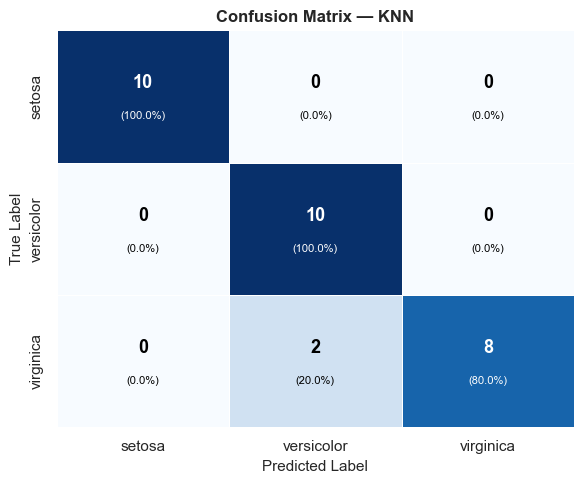

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\confusion_matrix_knn.png

[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\confusion_matrix_decision_tree.png


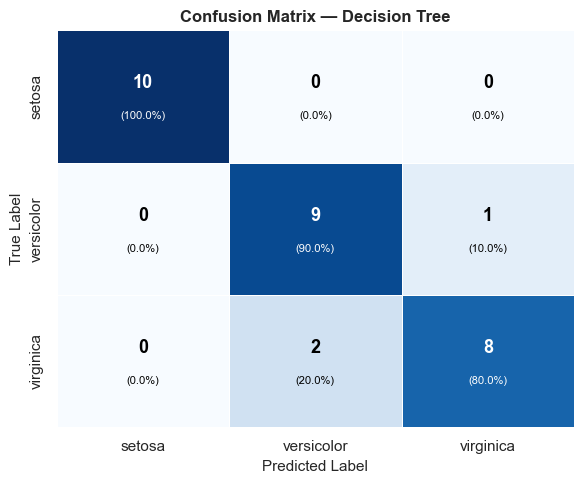

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\confusion_matrix_decision_tree.png

[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\confusion_matrix_svm.png


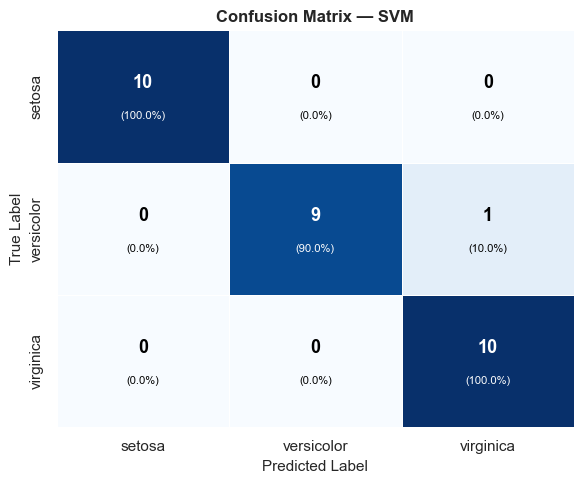

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\confusion_matrix_svm.png

[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\confusion_matrix_logistic_regression.png


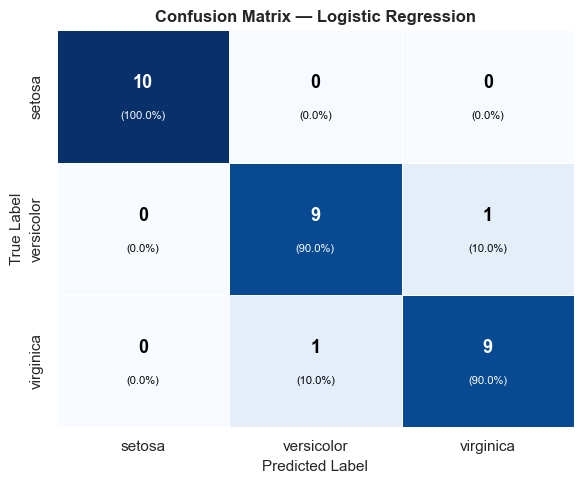

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\confusion_matrix_logistic_regression.png

[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\confusion_matrix_ensemble.png


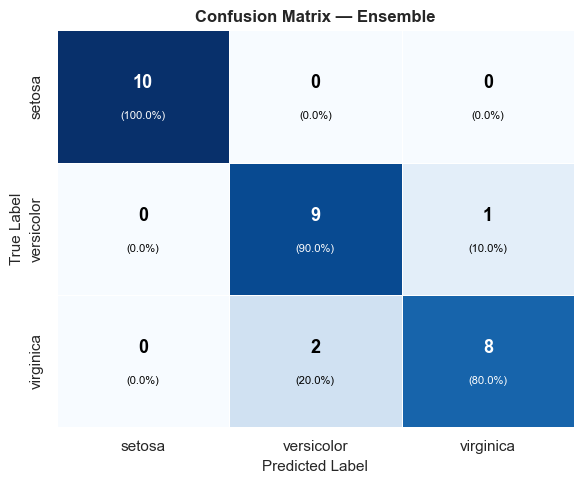

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\confusion_matrix_ensemble.png



In [27]:
# Cell 27 — Confusion matrices for all 5 models
for name, model in models.items():
    path = plot_confusion_matrix(model, X_test_scaled, y_test, name)
    plt.show()
    print(f"Saved: {path}\n")


[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\roc_curve_svm.png


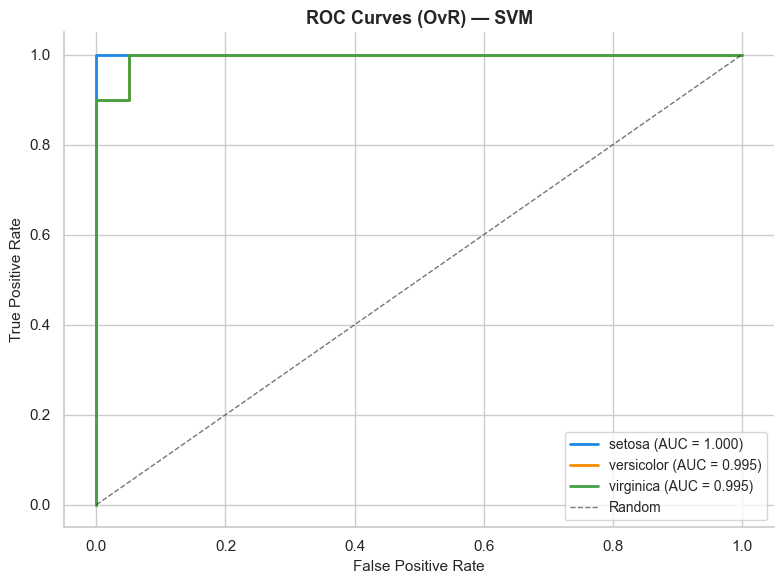

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\roc_curve_svm.png


In [28]:
# Cell 28 — ROC curves for the best model
best_model = models[best_model_name]
path = plot_roc_curves(best_model, X_test_scaled, y_test, best_model_name)
plt.show()
print(f"Saved: {path}")


## Section 7 — Cross-Validation & Statistical Significance

**5-fold stratified CV** on each model to estimate generalisation variance.  
A **paired t-test** between the top-2 models determines if the difference  
is statistically significant (p < 0.05).


In [29]:
# Cell 30 — 5-fold stratified cross-validation
# Use cloned (unfitted) models to avoid data leakage through fitted state
cv_models = {name: clone(model) for name, model in models.items()}

print("── 5-Fold CV Results (F1 macro) ─────────────────────")
cv_scores = cross_validate_all(cv_models, X_train_scaled, y_train, n_splits=5)

print("\n── CV Score Summary ─────────────────────────────────")
cv_summary = pd.DataFrame({
    name: {'mean': scores.mean(), 'std': scores.std(),
           'min': scores.min(),  'max': scores.max()}
    for name, scores in cv_scores.items()
}).T.round(4)
display(cv_summary)


── 5-Fold CV Results (F1 macro) ─────────────────────
  KNN                       CV F1: 0.9665 ± 0.0167
  Decision Tree             CV F1: 0.9496 ± 0.0171
  SVM                       CV F1: 0.9665 ± 0.0167
  Logistic Regression       CV F1: 0.9580 ± 0.0268
  Ensemble                  CV F1: 0.9580 ± 0.0268

── CV Score Summary ─────────────────────────────────


,mean,std,min,max
KNN,0.9665,0.0167,0.9582,1.0000
Decision Tree,0.9496,0.0171,0.9153,0.9582
SVM,0.9665,0.0167,0.9582,1.0000
Logistic Regression,0.9580,0.0268,0.9153,1.0000
Ensemble,0.9580,0.0268,0.9153,1.0000


[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\cv_boxplot.png


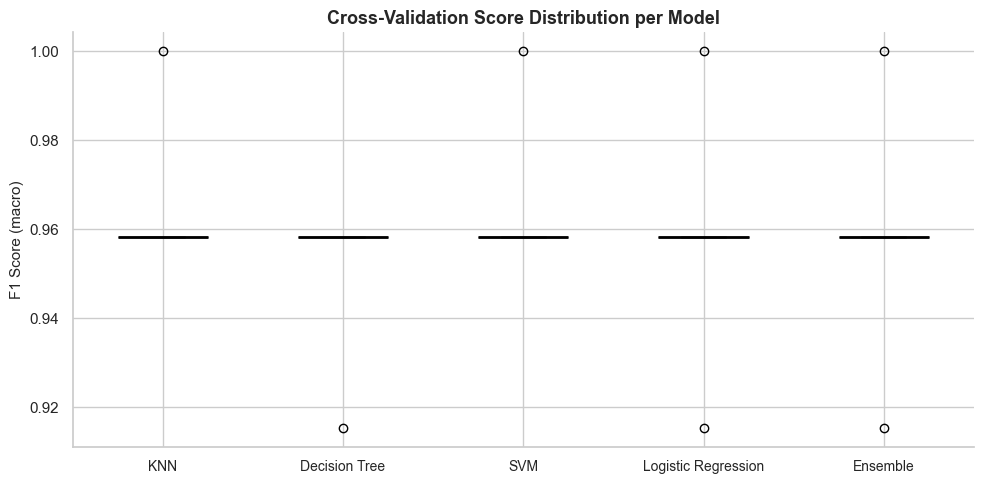

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\cv_boxplot.png


In [30]:
# Cell 31 — CV score distribution box plot
path = plot_cv_boxplot(cv_scores)
plt.show()
print(f"Saved: {path}")


In [31]:
# Cell 32 — Paired t-test: best vs second-best model
t_stat, p_value, best_cv_name, second_cv_name = statistical_significance_test(cv_scores)

print(f"Paired t-test: '{best_cv_name}'  vs  '{second_cv_name}'")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.4f}")
print()
if p_value < 0.05:
    print(f"  ✅ Significant (p < 0.05): '{best_cv_name}' is statistically better.")
else:
    print(f"  ℹ️  Not significant (p ≥ 0.05): models are statistically comparable.")


Paired t-test: 'KNN'  vs  'SVM'
  t-statistic : nan
  p-value     : nan

  ℹ️  Not significant (p ≥ 0.05): models are statistically comparable.


## Section 8 — Decision Tree Visualisation & Feature Importance

The Decision Tree provides **white-box interpretability** — every split rule  
is readable. Feature importances (Gini-based) reveal which measurements  
the tree found most discriminative.


[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\decision_tree.png


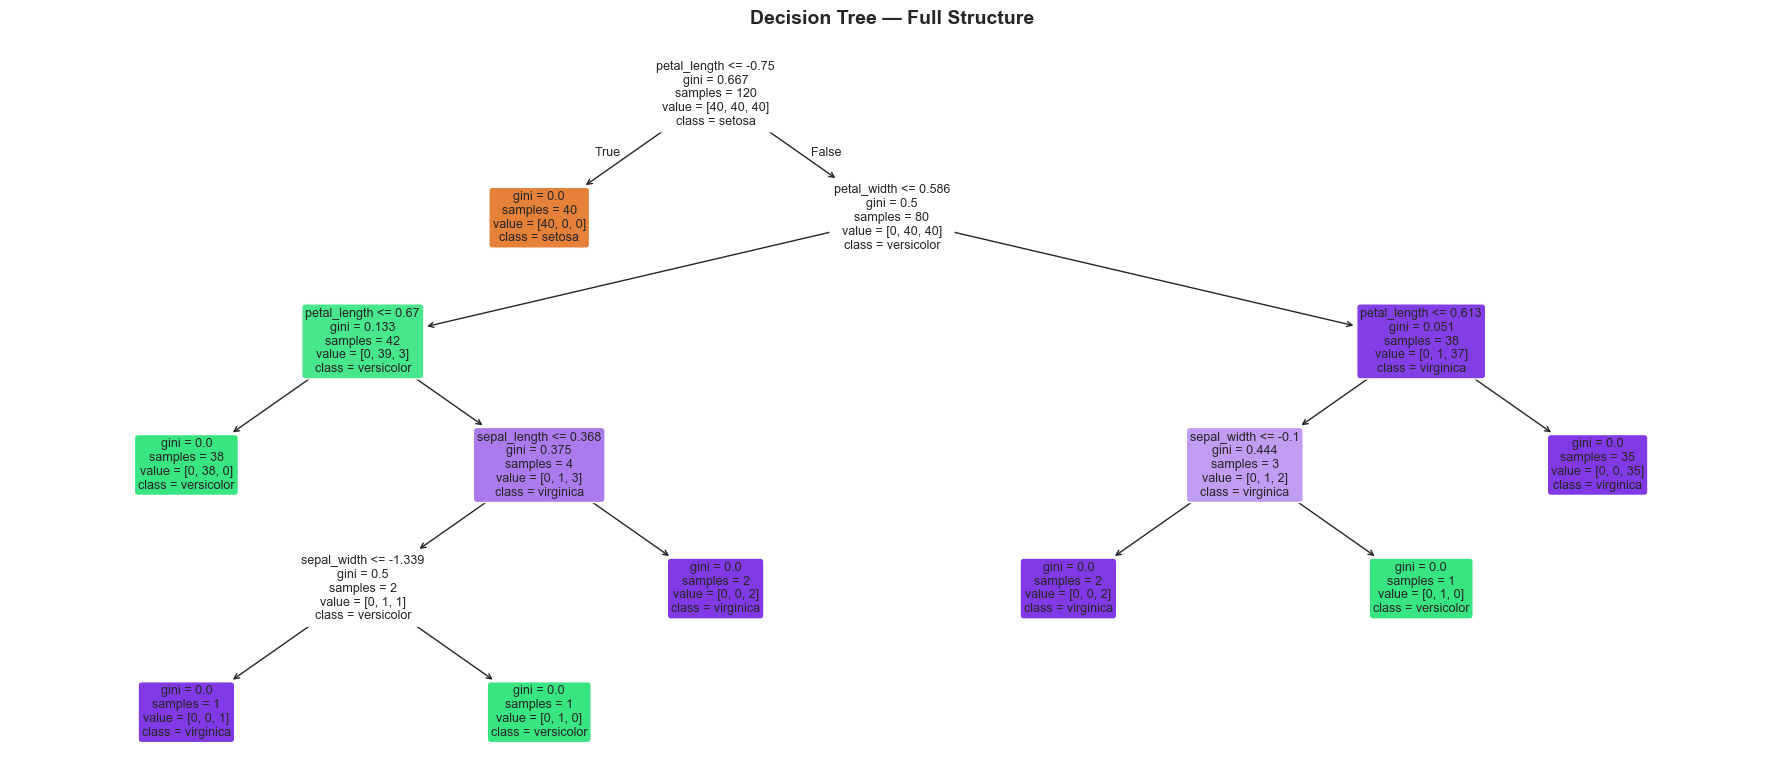

Tree saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\decision_tree.png
[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\feature_importance.png


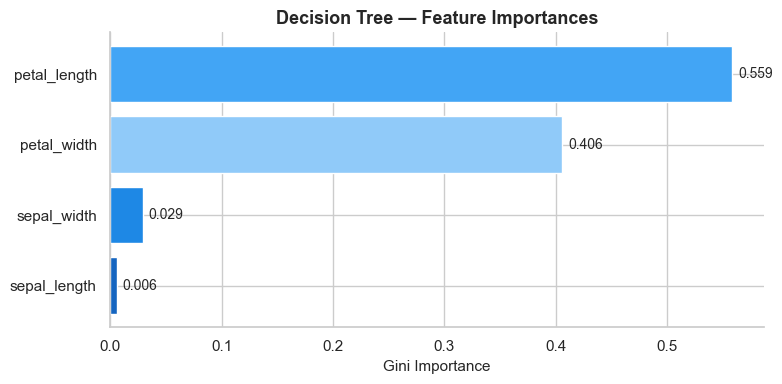

Importance saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\feature_importance.png


,Feature,Importance
2,petal_length,0.5586
3,petal_width,0.4060
1,sepal_width,0.0292
0,sepal_length,0.0062


In [32]:
# Cell 34 — Plot Decision Tree structure and feature importances
dt_model = models['Decision Tree']

path_tree = plot_decision_tree(dt_model, FEATURE_NAMES, TARGET_NAMES)
plt.show()
print(f"Tree saved: {path_tree}")

path_fi = plot_feature_importance(dt_model, FEATURE_NAMES)
plt.show()
print(f"Importance saved: {path_fi}")

importances_df = pd.DataFrame({
    'Feature':    FEATURE_NAMES,
    'Importance': dt_model.feature_importances_.round(4)
}).sort_values('Importance', ascending=False)
display(importances_df)


## Section 9 — Custom Weighted Scorer & Calibration Analysis

### Custom Weighted F1
Domain insight: **Versicolor/Virginica confusion is 2× more costly** than  
Setosa misclassification (due to practical botanical misidentification risk).  
Penalty weights: `{setosa: 1.0, versicolor: 2.0, virginica: 2.0}`

### Calibration
A well-calibrated model: predicted probability of 0.8 → 80% of those  
samples actually belong to that class. Measured by mean deviation from  
the perfect diagonal (lower = better calibration).


── Domain-Aware Weighted F1 ──────────────────────────
  SVM                     Weighted-F1 = 0.9599
  Logistic Regression     Weighted-F1 = 0.9200
  KNN                     Weighted-F1 = 0.9192
  Decision Tree           Weighted-F1 = 0.8797
  Ensemble                Weighted-F1 = 0.8797

── Calibration Quality (lower = better) ─────────────
  Decision Tree           Calib-dev = 0.0735
  KNN                     Calib-dev = 0.0833
  SVM                     Calib-dev = 0.0990
  Logistic Regression     Calib-dev = 0.1755
  Ensemble                Calib-dev = 0.1973
[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\calibration_curves.png


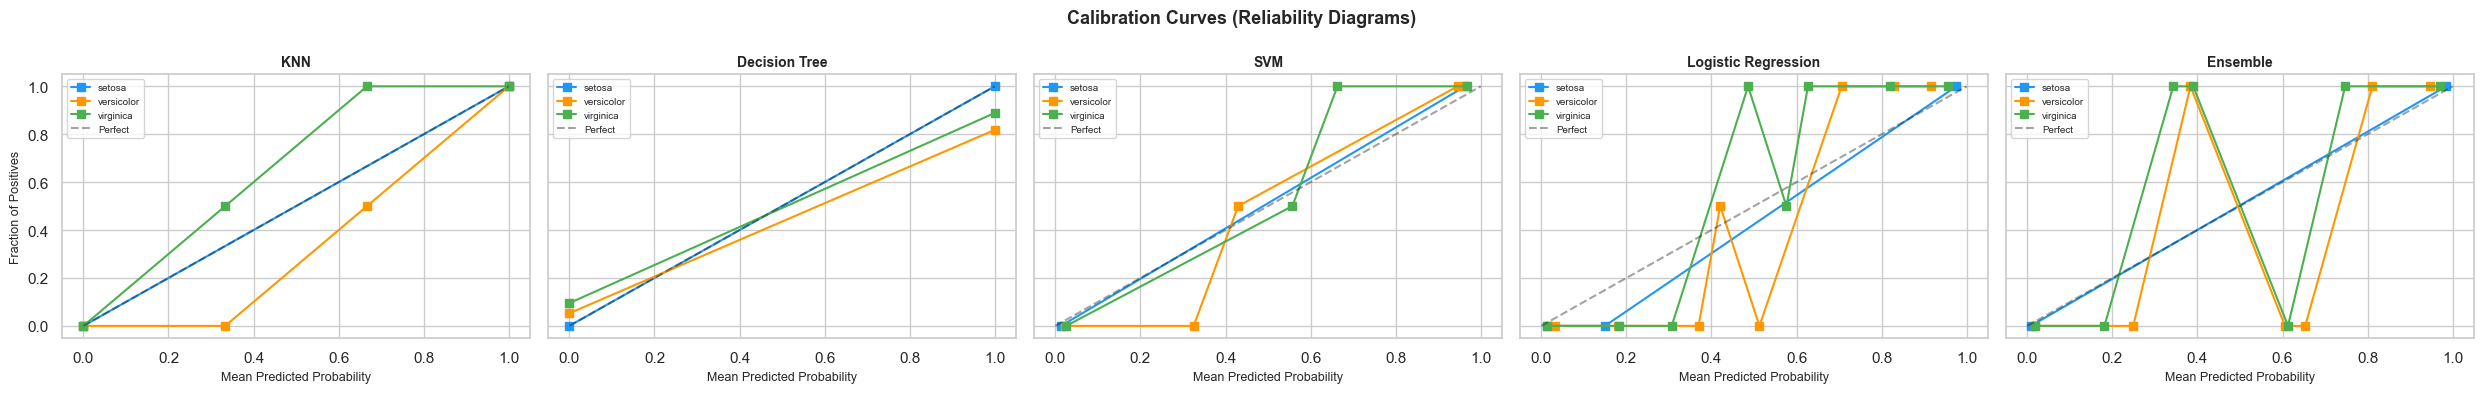


Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\calibration_curves.png


In [33]:
# Cell 36 — Domain-aware weighted F1 and calibration quality
print("── Domain-Aware Weighted F1 ──────────────────────────")
weighted_scores = {name: compute_weighted_f1(model, X_test_scaled, y_test)
                   for name, model in models.items()}
for name, score in sorted(weighted_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:<22}  Weighted-F1 = {score:.4f}")

print("\n── Calibration Quality (lower = better) ─────────────")
calib_scores = {name: compute_calibration_score(model, X_test_scaled, y_test)
                for name, model in models.items()}
for name, score in sorted(calib_scores.items(), key=lambda x: x[1]):
    print(f"  {name:<22}  Calib-dev = {score:.4f}")

path = plot_calibration_curves(models, X_test_scaled, y_test)
plt.show()
print(f"\nSaved: {path}")


## Section 10 — SHAP Explainability

**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution  
value for each individual prediction — grounded in cooperative game theory.

- `KernelExplainer` is model-agnostic (works with any sklearn estimator)
- Background data: 20 training samples (representative subsample)
- Output: per-class feature contribution beeswarm plots

> ⏳ **Note:** KernelExplainer is compute-intensive (~30–60s on Iris).


Computing SHAP values for: SVM
(This may take ~30–60 seconds — KernelExplainer is model-agnostic)



  0%|          | 0/30 [00:00<?, ?it/s]

SHAP values type: <class 'numpy.ndarray'>
SHAP shape (per class): (30, 4, 3)
[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\shap_summary_svm.png


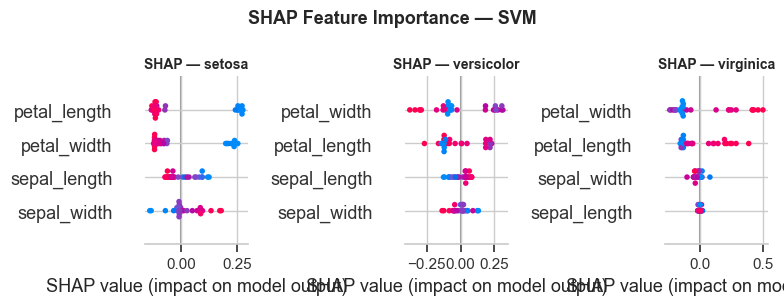

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\shap_summary_svm.png


In [34]:
# Cell 38 — SHAP KernelExplainer on the best model
print(f"Computing SHAP values for: {best_model_name}")
print("(This may take ~30–60 seconds — KernelExplainer is model-agnostic)\n")

# Background dataset: 20 representative training samples
np.random.seed(RANDOM_STATE)
background_idx = np.random.choice(len(X_train_scaled), size=20, replace=False)
background     = X_train_scaled[background_idx]

best_model_fn  = best_model.predict_proba
explainer      = shap.KernelExplainer(best_model_fn, background)
shap_values    = explainer.shap_values(X_test_scaled, nsamples=50)

print(f"SHAP values type: {type(shap_values)}")
print(f"SHAP shape (per class): {np.array(shap_values).shape}")

path = plot_shap_summary(shap_values, X_test_scaled,
                          FEATURE_NAMES, best_model_name)
plt.show()
print(f"Saved: {path}")


## Section 11 — Learning Curve Analysis

Learning curves answer: *"Does my model benefit from more training data?"*

- **Rising val score + gap closing** → need more data
- **Both scores plateau** → data sufficient, tune model
- **High train, low val** → overfitting → regularise or simplify

Computed on the best model using 5-fold CV across 6 training size increments.


[Visualizer] Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\learning_curve_svm.png


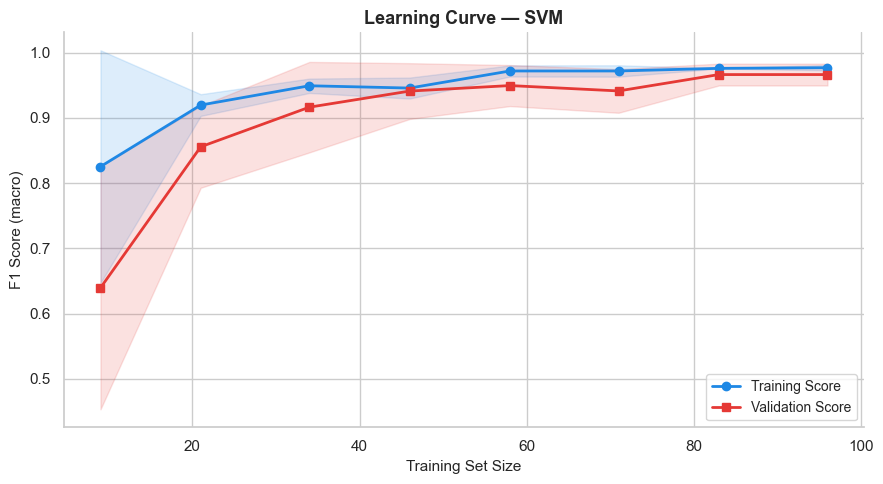

Saved: c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\assets\learning_curve_svm.png

Final training F1   : 0.9771 ± 0.0042
Final validation F1 : 0.9665  ± 0.0167
Train-Val gap       : 0.0105  (healthy)


In [35]:
# Cell 40 — Learning curve for best model
lc_model = clone(best_model)

train_sizes_abs, train_scores_lc, val_scores_lc = learning_curve(
    lc_model,
    X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1
)

path = plot_learning_curve(train_sizes_abs, train_scores_lc,
                            val_scores_lc, best_model_name)
plt.show()
print(f"Saved: {path}")

print(f"\nFinal training F1   : {train_scores_lc[-1].mean():.4f} ± {train_scores_lc[-1].std():.4f}")
print(f"Final validation F1 : {val_scores_lc[-1].mean():.4f}  ± {val_scores_lc[-1].std():.4f}")
gap = train_scores_lc[-1].mean() - val_scores_lc[-1].mean()
print(f"Train-Val gap       : {gap:.4f}  ({'slight overfit' if gap > 0.05 else 'healthy'})")


## Section 12 — sklearn Pipeline & Model Persistence

A `sklearn.pipeline.Pipeline` chains **StandardScaler → classifier** into  
a single object. Benefits:
- No manual scaling at inference time
- Safe to use with `GridSearchCV` (no leakage across CV folds)
- One `joblib` file contains both the scaler and the model

Model artifact is saved to `models/best_model_pipeline.pkl`.


In [37]:
# Cell 42 — Build production pipeline, fit, save, and reload-verify
# Get an unfitted copy of the best base model (not Ensemble, which already has scaler logic)
model_map_unfitted = {
    'KNN':                 KNeighborsClassifier(n_neighbors=optimal_k),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Ensemble':            build_voting_classifier(optimal_k=optimal_k),
}

best_model_key = str(best_model_name)
pipeline_model = model_map_unfitted[best_model_key] if best_model_key in model_map_unfitted else KNeighborsClassifier(n_neighbors=optimal_k)

production_pipeline = build_pipeline(pipeline_model)

# Fit on RAW (unscaled) training data — pipeline handles scaling internally
production_pipeline.fit(X_train, y_train)

pipeline_path = os.path.join('..', 'models', 'best_model_pipeline.pkl')
joblib.dump(production_pipeline, pipeline_path)
print(f"✅ Pipeline saved: {pipeline_path}")

# Verify: reload and score must match
reloaded = joblib.load(pipeline_path)
reload_acc = accuracy_score(y_test, reloaded.predict(X_test))
print(f"✅ Reloaded pipeline accuracy (on raw X_test): {reload_acc:.4f}")
print(f"   Pipeline steps: {[name for name, _ in reloaded.steps]}")


✅ Pipeline saved: ..\models\best_model_pipeline.pkl
✅ Reloaded pipeline accuracy (on raw X_test): 0.9667
   Pipeline steps: ['scaler', 'classifier']


##  Section 12.5 — Interactive Prediction Interface (ipywidgets)

Use the sliders below to set flower measurements.
The best saved model predicts the species and confidence **in real time**.

> Run this cell then adjust the sliders — no re-run needed.

In [39]:
# ── Interactive Prediction Widget
import ipywidgets as widgets
from IPython.display import display, clear_output
import joblib, os, numpy as np

# ── Load saved pipeline once
_pipeline_path = os.path.join(MODEL_DIR, 'best_model_pipeline.pkl')

try:
    _saved_pipeline = joblib.load(_pipeline_path)
    print(f"✅ Loaded pipeline from: {_pipeline_path}")
except FileNotFoundError:
    _saved_pipeline = None
    print("⚠️  No saved pipeline found. Run Cell 42 first to save the model.")

# ── Species metadata
_SPECIES_EMOJI = {
    'setosa':     '🌸',
    'versicolor': '🌺',
    'virginica':  '🌷'
}

# ── Widget definitions
_style  = {'description_width': '160px'}
_layout = widgets.Layout(width='420px')

sl_sepal_len = widgets.FloatSlider(
    value=5.1, min=4.0, max=8.0, step=0.1,
    description='Sepal Length (cm):',
    style=_style, layout=_layout,
    continuous_update=True
)
sl_sepal_wid = widgets.FloatSlider(
    value=3.5, min=2.0, max=4.5, step=0.1,
    description='Sepal Width  (cm):',
    style=_style, layout=_layout,
    continuous_update=True
)
sl_petal_len = widgets.FloatSlider(
    value=1.4, min=1.0, max=7.0, step=0.1,
    description='Petal Length (cm):',
    style=_style, layout=_layout,
    continuous_update=True
)
sl_petal_wid = widgets.FloatSlider(
    value=0.2, min=0.1, max=2.5, step=0.1,
    description='Petal Width  (cm):',
    style=_style, layout=_layout,
    continuous_update=True
)

_output = widgets.Output()

# ── Prediction function with confidence thresholding and visual feedback
CONFIDENCE_THRESHOLD = 0.75  # Minimum probability to be "certain"
def _predict(sepal_length, sepal_width, petal_length, petal_width):
    with _output:
        clear_output(wait=True)

        if _saved_pipeline is None:
            print("⚠️  No model loaded. Please run Cell 42 first.")
            return

        # Build input array — shape (1, 4)
        X_input = np.array([[sepal_length, sepal_width,
                              petal_length, petal_width]])

        # predict() returns string label directly
        pred_name   = _saved_pipeline.predict(X_input)[0]
        proba       = _saved_pipeline.predict_proba(X_input)[0]

        # Get integer index from TARGET_NAMES for proba indexing
        target_list = list(TARGET_NAMES)
        pred_idx    = target_list.index(pred_name)
        confidence  = proba[pred_idx] * 100
        emoji       = _SPECIES_EMOJI[pred_name]

        threshold_pct = CONFIDENCE_THRESHOLD * 100
        certain = confidence >= threshold_pct

        print("="*50)
        print("  🌸  IRIS SPECIES PREDICTOR")
        print("="*50)
        print(f"  Input Features")
        print(f"  ├─ Sepal Length : {sepal_length:.1f} cm")
        print(f"  ├─ Sepal Width  : {sepal_width:.1f} cm")
        print(f"  ├─ Petal Length : {petal_length:.1f} cm")
        print(f"  └─ Petal Width  : {petal_width:.1f} cm")
        print()
        if certain:
            print(f"  Prediction  : {emoji}  {pred_name.upper()}")
            print(f"  Confidence  : {confidence:.1f}%  ✅")
        else:
            print(f"  Prediction  : ⚠️  UNCERTAIN  (below {threshold_pct:.0f}% threshold)")
            print(f"  Best guess  : {emoji}  {pred_name.upper()}")
            print(f"  Confidence  : {confidence:.1f}%  ❌")
        print()
        print("  Class Probabilities")
        for name, prob in zip(TARGET_NAMES, proba):
            bar = '█' * int(prob * 30)
            print(f"  {_SPECIES_EMOJI[name]}  {name:<12} {prob*100:5.1f}%  {bar}")
        print("="*50)

# ── Wire sliders to prediction function
_interactive = widgets.interactive_output(
    _predict,
    {
        'sepal_length': sl_sepal_len,
        'sepal_width' : sl_sepal_wid,
        'petal_length': sl_petal_len,
        'petal_width' : sl_petal_wid,
    }
)

# ── Render UI
_header = widgets.HTML(
    value="<h3 style='color:#4a7c59;margin-bottom:4px'>"
          "🎛️ Adjust sliders to predict Iris species in real time</h3>"
)
_panel = widgets.VBox([
    _header,
    sl_sepal_len, sl_sepal_wid,
    sl_petal_len, sl_petal_wid,
    _output
])

display(_panel)
_interactive  # trigger first prediction with default slider values

✅ Loaded pipeline from: C:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\models\best_model_pipeline.pkl


Output()

## Section 13 — Model Card & Experiment Log

A **Model Card** is a standardised summary document for ML models,  
popularised by Google (Mitchell et al., 2019). It covers:

- Model identity and intended use
- Training and evaluation details
- Performance metrics
- Limitations and ethical considerations

The experiment is also appended to `logs/experiment_log.csv` for audit trail.


In [41]:
# Cell 44 — Generate Model Card and log the experiment
best_metrics = results[best_model_name]

# ── Experiment log entry
log_entry = {
    'timestamp':    datetime.datetime.now().isoformat(),
    'author':       'Ali Ahmad',
    'project':      'DecodeLabs AI Project 2',
    'dataset':      'Iris (150 samples, 4 features, 3 classes)',
    'data_hash':    data_hash[:16] + '...',
    'data_source':  source_used,
    'best_model':   best_model_name,
    'optimal_k':    optimal_k,
    'test_size':    TEST_SIZE,
    'random_state': RANDOM_STATE,
    **{f'test_{k}': v for k, v in best_metrics.items()},
    'weighted_f1':  round(weighted_scores[best_model_name], 4),
    'calib_dev':    round(calib_scores[best_model_name],   4),
}

log_experiment(log_entry, log_file=os.path.join('..', 'logs', 'experiment_log.csv'))

# ── Model Card
sep = "=" * 62
model_card = f"""
{sep}
  MODEL CARD — DecodeLabs AI Project 2
{sep}
  Author           : Ali Ahmad
  Organisation     : DecodeLabs (Batch 2026)
  Date             : {datetime.datetime.now().strftime("%Y-%m-%d")}
  Project          : Data Classification Using AI

── Model Identity
  Best Model       : {best_model_name}
  Algorithm        : {type(best_model).__name__}
  Optimal k (KNN)  : {optimal_k}

── Dataset
  Name             : Iris Benchmark
  Source           : {source_used}
  Samples          : 150  (50 per class — balanced)
  Features         : {FEATURE_NAMES}
  Classes          : {TARGET_NAMES}
  Data Hash        : {data_hash[:32]}...

── Training Details
  Train size       : {X_train_scaled.shape[0]} samples (80%)
  Test  size       : {X_test_scaled.shape[0]} samples (20%)
  Scaler           : StandardScaler (fit on train only)
  CV Strategy      : StratifiedKFold (5 folds)
  Random state     : {RANDOM_STATE}

── Performance Metrics (Test Set)
  Accuracy         : {best_metrics['accuracy']:.4f}
  F1 (macro)       : {best_metrics['f1']:.4f}
  Precision (macro): {best_metrics['precision']:.4f}
  Recall (macro)   : {best_metrics['recall']:.4f}
  ROC-AUC (OvR)    : {best_metrics['roc_auc']:.4f}
  Weighted F1      : {weighted_scores[best_model_name]:.4f}
  Calibration dev  : {calib_scores[best_model_name]:.4f}

── Intended Use
  This model classifies Iris flower species from 4 physical
  measurements. Intended for educational demonstrations of
  supervised learning pipelines.

── Limitations
  • Trained on only 150 samples — not production-scale
  • Generalisation to non-Iris botanical domains is untested
  • KernelExplainer SHAP is approximate (50 nsamples)

── Ethical Considerations
  No sensitive personal data used. Iris is a classical ML
  benchmark with no known harmful applications.

── Artifacts
  Pipeline         : models/best_model_pipeline.pkl
  Experiment log   : logs/experiment_log.csv
  Visualisations   : assets/*.png
{sep}
"""

print(model_card)

# Save Model Card as text file
card_path = os.path.join('..', 'models', 'model_card.txt')
with open(card_path, 'w') as f:
    f.write(model_card)
print(f"✅ Model Card saved: {card_path}")
print("\n🎉 Project 2 Complete! Pipeline, artifacts, and logs ready for submission.")


[Evaluator] Experiment logged to: ..\logs\experiment_log.csv

  MODEL CARD — DecodeLabs AI Project 2
  Author           : Ali Ahmad
  Organisation     : DecodeLabs (Batch 2026)
  Date             : 2026-05-27
  Project          : Data Classification Using AI

── Model Identity
  Best Model       : SVM
  Algorithm        : SVC
  Optimal k (KNN)  : 3

── Dataset
  Name             : Iris Benchmark
  Source           : huggingface
  Samples          : 150  (50 per class — balanced)
  Features         : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
  Classes          : ['setosa', 'versicolor', 'virginica']
  Data Hash        : 67037d1d5dd80fe8dcd69abe1ead3074...

── Training Details
  Train size       : 120 samples (80%)
  Test  size       : 30 samples (20%)
  Scaler           : StandardScaler (fit on train only)
  CV Strategy      : StratifiedKFold (5 folds)
  Random state     : 42

── Performance Metrics (Test Set)
  Accuracy         : 0.9667
  F1 (macro)       : 0.9666


In [42]:
# ── Requirements Freeze ───────────────────────────────────────────────────────
# Captures exact installed versions of every package used in this project
# Writes requirements_frozen.txt to project root for full reproducibility

import importlib.metadata as importlib_metadata
import os

# Packages used in this project
PACKAGES_USED = [
    'scikit-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'datasets',
    'joblib',
    'scipy',
    'shap',
    'ipywidgets',
    'ipykernel',
    'nbformat',
    'pytest',
]

print("="*60)
print("Requirements Freeze")
print("="*60)

frozen_lines = []
missing      = []

for pkg in sorted(PACKAGES_USED):
    try:
        version = importlib_metadata.version(pkg)
        line    = f"{pkg}=={version}"
        frozen_lines.append(line)
        print(f"  ✅  {line}")
    except importlib_metadata.PackageNotFoundError:
        missing.append(pkg)
        print(f"  ❌  {pkg}  — not installed")

# Write to file
frozen_path = os.path.join(os.getcwd(), 'requirements_frozen.txt')
with open(frozen_path, 'w') as f:
    f.write("# Auto-generated by Cell 45 — exact environment snapshot\n")
    f.write(f"# Generated: {__import__('datetime').datetime.now().isoformat()}\n\n")
    f.write('\n'.join(frozen_lines))
    f.write('\n')

print()
print(f"  Written to : {frozen_path}")
print(f"  Packages   : {len(frozen_lines)} pinned")
if missing:
    print(f"  Missing    : {', '.join(missing)}")
print("="*60)
print("  To recreate this environment exactly:")
print(f"  pip install -r requirements_frozen.txt")
print("="*60)

Requirements Freeze
  ✅  datasets==4.8.5
  ✅  ipykernel==6.28.0
  ✅  ipywidgets==7.8.1
  ✅  joblib==1.5.3
  ✅  matplotlib==3.10.9
  ✅  nbformat==5.10.4
  ✅  numpy==1.26.4
  ✅  pandas==3.0.3
  ✅  pytest==7.4.4
  ✅  scikit-learn==1.8.0
  ✅  scipy==1.17.1
  ✅  seaborn==0.13.2
  ✅  shap==0.51.0

  Written to : c:\Users\pakistan\OneDrive\Desktop\decodelabs-ai-project2\notebooks\requirements_frozen.txt
  Packages   : 13 pinned
  To recreate this environment exactly:
  pip install -r requirements_frozen.txt
